## 4. Exploratory Data Analysis

### Objective

Explore the engineered early-risk dataset using the actual student-course records and the features available within the first **28 days**.

This notebook focuses on:
- the final risk-group distribution,
- differences across course modules and demographic groups,
- early assessment performance and participation,
- early VLE engagement,
- the relationship between academic performance and engagement,
- correlations and descriptive differences among numeric early-warning features.

The goal is to identify **observed patterns and candidate predictive signals** before model development. These findings are descriptive associations; they do not by themselves establish causation or model importance.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

features = pd.read_csv(
    PROCESSED_DIR / "early_risk_features.csv"
)

print("Rows:", len(features))
print("Columns:", len(features.columns))

Rows: 32593
Columns: 26


In [3]:
features.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,is_at_risk,registered_before_start,early_assessments_taken,early_mean_score,early_median_score,early_max_score,early_score_std,early_missing_scores,early_assessment_weight,total_clicks,active_days,active_sites,avg_clicks_per_active_day,no_early_vle_activity
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,-159.0,0,1,1.0,78.0,78.0,78.0,NaN,0.0,10.0,400.0,8.0,24.0,50.000000,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,-53.0,0,1,1.0,70.0,70.0,70.0,NaN,0.0,10.0,609.0,19.0,34.0,32.052632,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,-92.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.0,12.0,22.0,21.666667,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,-52.0,0,1,1.0,72.0,72.0,72.0,NaN,0.0,10.0,469.0,22.0,31.0,21.318182,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,-176.0,0,1,1.0,69.0,69.0,69.0,NaN,0.0,10.0,559.0,24.0,34.0,23.291667,0


## 4.1 Dataset Overview

We first verify the size, granularity, data types, and remaining missing values in the engineered feature table.

The expected unit of analysis is one **student-course-presentation** record. This is important because all later comparisons should be made at the same student-course level used for early-risk modeling.


In [4]:
print("Shape:", features.shape)

print(
    "Unique student-course records:",
    features[
        ["code_module", "code_presentation", "id_student"]
    ].drop_duplicates().shape[0]
)

Shape: (32593, 26)
Unique student-course records: 32593


In [5]:
features.dtypes

code_module                   object
code_presentation             object
id_student                     int64
gender                        object
region                        object
highest_education             object
imd_band                      object
age_band                      object
num_of_prev_attempts           int64
studied_credits                int64
disability                    object
date_registration            float64
is_at_risk                     int64
registered_before_start        int64
early_assessments_taken      float64
early_mean_score             float64
early_median_score           float64
early_max_score              float64
early_score_std              float64
early_missing_scores         float64
early_assessment_weight      float64
total_clicks                 float64
active_days                  float64
active_sites                 float64
avg_clicks_per_active_day    float64
no_early_vle_activity          int64
dtype: object

In [6]:
features.isna().sum().sort_values(ascending=False).head(15)

early_score_std              31696
early_median_score           12113
early_max_score              12113
early_mean_score             12113
early_assessment_weight      12099
early_missing_scores         12099
early_assessments_taken      12099
total_clicks                  3801
active_sites                  3801
active_days                   3801
avg_clicks_per_active_day     3801
date_registration               45
studied_credits                  0
num_of_prev_attempts             0
highest_education                0
dtype: int64

## Insight

The engineered dataset contains **32,593 rows and 26 columns**, with exactly **32,593 unique student-course-presentation records**. This confirms that the feature table has preserved the intended one-record-per-student-course granularity.

Missingness is concentrated in early assessment and VLE-derived features rather than being spread uniformly across the dataset. In particular, `early_assessments_taken` is missing for **12,099 records**, while `total_clicks` and the other main VLE engagement measures are missing for **3,801 records**. This pattern is consistent with students having no recorded early assessment or VLE activity, so the missing values should be interpreted in the context of feature construction rather than treated as generic data-quality errors.


## 4.2 Target Distribution

The target `is_at_risk` labels a student-course record as **At Risk** when the final outcome was **Fail or Withdrawn**, and **Not At Risk** otherwise.

Before comparing predictors, we check the target balance because it determines how large the two outcome groups are and helps us choose appropriate evaluation metrics later.


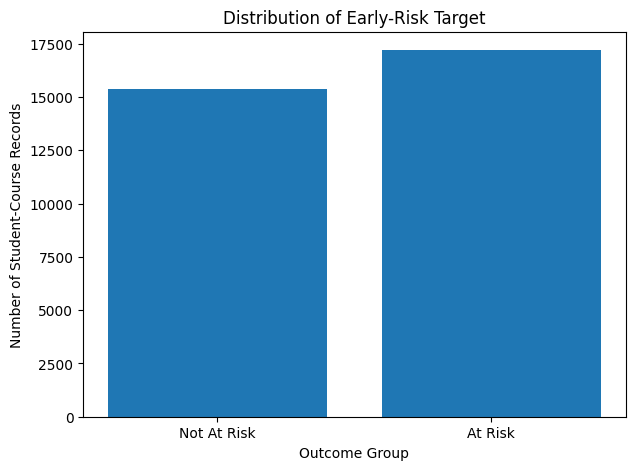

In [7]:
target_counts = (
    features["is_at_risk"]
    .value_counts()
    .sort_index()
)

target_labels = ["Not At Risk", "At Risk"]

plt.figure(figsize=(7, 5))
plt.bar(target_labels, target_counts.values)
plt.title("Distribution of Early-Risk Target")
plt.ylabel("Number of Student-Course Records")
plt.xlabel("Outcome Group")
plt.show()

In [8]:
target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": (
        target_counts / target_counts.sum() * 100
    ).round(2)
})

target_summary.index = ["Not At Risk", "At Risk"]

target_summary

,count,percentage
Not At Risk,15385,47.2
At Risk,17208,52.8


## Insight

The target is **not strongly imbalanced** in this dataset: **17,208 records (52.8%)** are At Risk and **15,385 (47.2%)** are Not At Risk.

The two groups are therefore relatively close in size. This means that the later modeling stage should not justify metric choices on the assumption of severe class imbalance. Accuracy can still be reported, but risk-screening metrics such as precision, recall, F1, ROC-AUC, and—where useful—PR-AUC will give a more complete view of model performance.


## 4.3 Risk Across Course Modules

We compare the at-risk rate across course modules to determine whether the observed risk level is similar across the curriculum or varies substantially by module.


In [9]:
module_risk = (
    features
    .groupby("code_module")["is_at_risk"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

module_risk["risk_percentage"] = (
    module_risk["mean"] * 100
).round(2)

module_risk

,mean,count,risk_percentage
code_module,,,
CCC,0.621561,4434,62.16
DDD,0.583865,6272,58.39
FFF,0.530018,7762,53.00
BBB,0.525351,7909,52.54
EEE,0.437628,2934,43.76
GGG,0.402526,2534,40.25
AAA,0.290107,748,29.01


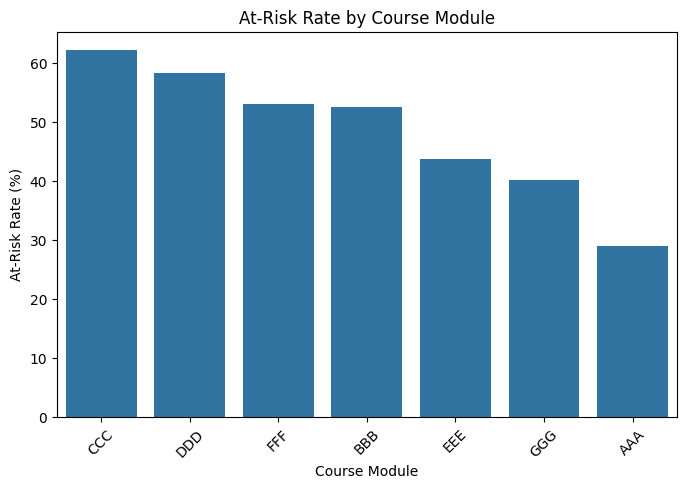

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=module_risk.reset_index(),
    x="code_module",
    y="risk_percentage"
)

plt.title("At-Risk Rate by Course Module")
plt.xlabel("Course Module")
plt.ylabel("At-Risk Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Insight

Risk varies substantially across modules.

- **CCC has the highest at-risk rate: 62.16%**.
- **DDD follows at 58.39%**.
- FFF and BBB are close to the overall level at **53.00%** and **52.54%**.
- EEE is lower at **43.76%**, followed by GGG at **40.25%**.
- **AAA has the lowest rate at 29.01%**, but it also has only **748 records**, much fewer than the larger modules.

The gap between the highest and lowest observed module rates is about **33 percentage points**. This is large enough to justify keeping course/module context in the modeling stage, while remembering that these are descriptive differences and may reflect differences in course structure or student composition rather than a causal effect of the module itself.


## 4.4 Demographic Risk: Age

The case study asks whether risk differs across age groups. We compare the observed at-risk rate and group size for each age band.


In [11]:
age_risk = (
    features
    .groupby("age_band")["is_at_risk"]
    .agg(["mean", "count"])
)

age_risk["risk_percentage"] = (
    age_risk["mean"] * 100
).round(2)

age_risk

,mean,count,risk_percentage
age_band,,,
0-35,0.549686,22944,54.97
35-55,0.478427,9433,47.84
55<=,0.384259,216,38.43


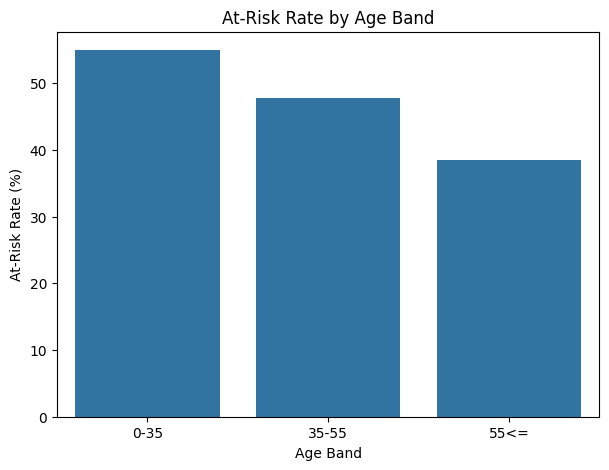

In [12]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=age_risk.reset_index(),
    x="age_band",
    y="risk_percentage"
)

plt.title("At-Risk Rate by Age Band")
plt.xlabel("Age Band")
plt.ylabel("At-Risk Rate (%)")
plt.show()

## Insight

The observed at-risk rate decreases across the age bands:

- **0–35:** 54.97% at risk (**22,944 records**)
- **35–55:** 47.84% (**9,433 records**)
- **55≤:** 38.43% (**216 records**)

The youngest group is about **7.1 percentage points** above the 35–55 group and about **16.5 points** above the 55≤ group.

However, the 55≤ group is very small (216 records), so its estimate is less stable than the two larger groups. Age therefore appears to be a useful contextual variable to test, but the EDA alone does not show that age causes higher or lower risk.


## 4.5 Demographic Risk: Prior Education

We compare at-risk rates across the students' highest recorded education level.

The group sizes are also important here because some education categories are much smaller than others.


In [13]:
education_risk = (
    features
    .groupby("highest_education")["is_at_risk"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

education_risk["risk_percentage"] = (
    education_risk["mean"] * 100
).round(2)

education_risk

,mean,count,risk_percentage
highest_education,,,
No Formal quals,0.703170,347,70.32
Lower Than A Level,0.611491,13158,61.15
A Level or Equivalent,0.479672,14045,47.97
HE Qualification,0.438266,4730,43.83
Post Graduate Qualification,0.345048,313,34.50


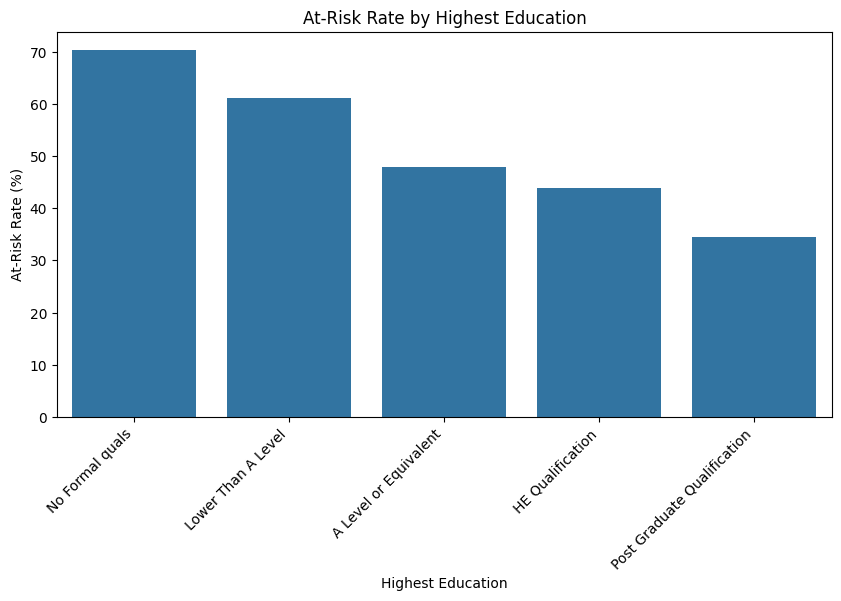

In [14]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=education_risk.reset_index(),
    x="highest_education",
    y="risk_percentage"
)

plt.title("At-Risk Rate by Highest Education")
plt.xlabel("Highest Education")
plt.ylabel("At-Risk Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Insight

There is a clear descriptive gradient across education groups:

- **No Formal quals:** 70.32% at risk (**347 records**)
- **Lower Than A Level:** 61.15% (**13,158**)
- **A Level or Equivalent:** 47.97% (**14,045**)
- **HE Qualification:** 43.83% (**4,730**)
- **Post Graduate Qualification:** 34.50% (**313**)

The observed rate differs by almost **36 percentage points** between the highest-risk and lowest-risk education groups. The two smallest groups—No Formal quals and Post Graduate Qualification—should be interpreted cautiously because their sample sizes are much smaller.

Overall, prior education shows a stronger descriptive difference than the small difference seen in early assessment participation, making it a reasonable contextual feature to evaluate in modeling. These results remain associations, not causal effects.


## 4.6 Demographic Risk: Socioeconomic Background

The `imd_band` variable provides socioeconomic context. We compare at-risk rates across the available bands and keep the `Unknown` category because missingness was deliberately preserved during cleaning.


In [15]:
imd_risk = (
    features
    .groupby("imd_band")["is_at_risk"]
    .agg(["mean", "count"])
)

imd_risk["risk_percentage"] = (
    imd_risk["mean"] * 100
).round(2)

imd_risk

,mean,count,risk_percentage
imd_band,,,
0-10%,0.648445,3311,64.84
10-20,0.613766,3516,61.38
20-30%,0.592501,3654,59.25
30-40%,0.530941,3539,53.09
40-50%,0.534091,3256,53.41
50-60%,0.512164,3124,51.22
60-70%,0.480895,2905,48.09
70-80%,0.484891,2879,48.49
80-90%,0.459450,2762,45.94


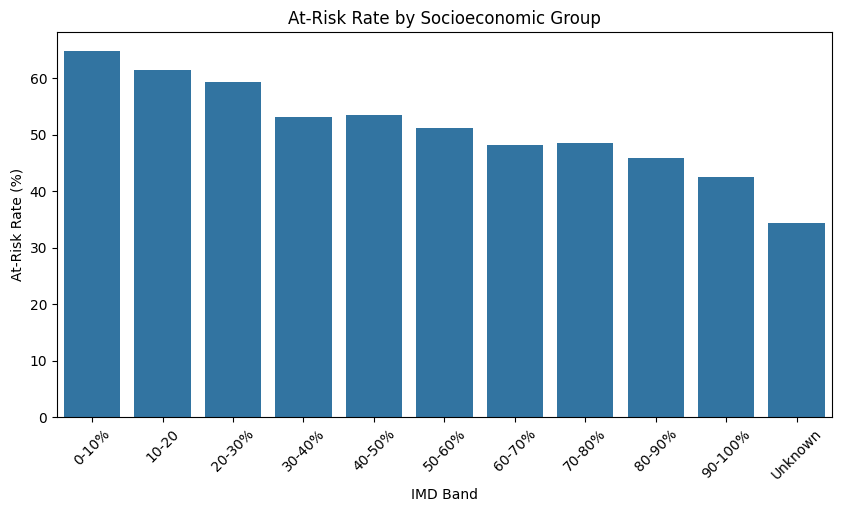

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=imd_risk.reset_index(),
    x="imd_band",
    y="risk_percentage"
)

plt.title("At-Risk Rate by Socioeconomic Group")
plt.xlabel("IMD Band")
plt.ylabel("At-Risk Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Insight

The observed risk rate generally decreases as the `imd_band` moves from the lowest to the highest band:

- **0–10%:** 64.84% at risk
- **10–20%:** 61.38%
- **20–30%:** 59.25%
- **30–40%:** 53.09%
- **40–50%:** 53.41%
- **50–60%:** 51.22%
- **60–70%:** 48.09%
- **70–80%:** 48.49%
- **80–90%:** 45.94%
- **90–100%:** 42.47%

That is a drop of about **22.4 percentage points** from the 0–10% group to the 90–100% group.

The `Unknown` group has a notably lower observed rate (**34.29%, 1,111 records**) than every known band. Because this group represents missing socioeconomic information rather than a real socioeconomic band, it should **not** be interpreted as evidence that missing IMD information itself is protective. It simply confirms that missingness is associated with a different outcome mix and should be handled carefully during modeling.


## 4.7 Early Assessment Performance

We examine whether assessment performance available within the first **28 days** differs between students who were eventually At Risk and those who were Not At Risk.

The comparison uses aggregated early assessment features rather than future assessment results.


In [17]:
assessment_risk = (
    features
    .groupby("is_at_risk")[
        [
            "early_mean_score",
            "early_median_score",
            "early_max_score",
            "early_assessments_taken"
        ]
    ]
    .mean()
)

assessment_risk.index = ["Not At Risk", "At Risk"]

assessment_risk

,early_mean_score,early_median_score,early_max_score,early_assessments_taken
Not At Risk,76.964223,76.964223,77.195625,1.040828
At Risk,65.945078,65.945078,66.283429,1.048139


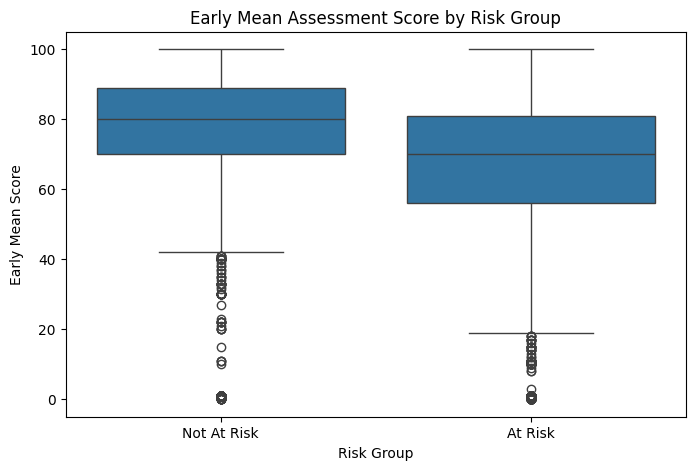

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=features,
    x="is_at_risk",
    y="early_mean_score"
)

plt.title("Early Mean Assessment Score by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Early Mean Score")

plt.xticks(
    [0, 1],
    ["Not At Risk", "At Risk"]
)

plt.show()

## Insight

Early assessment performance shows a substantial difference between the two outcome groups.

The mean `early_mean_score` is:
- **76.96** for Not At Risk students
- **65.95** for At Risk students

That is a difference of about **11.0 score points**.

The median and maximum early scores show the same directional pattern:
- median: **76.96 vs 65.95**
- maximum: **77.20 vs 66.28**

In contrast, the average number of early assessments taken is almost identical (**1.041 vs 1.048**). This means that in this dataset, **how well students performed on the early assessment appears much more informative descriptively than simply how many early assessments they took**.


## 4.8 Early Assessment Participation

Performance alone may not capture every form of early academic engagement. We therefore check whether the number of early assessments taken differs between the two risk groups.


In [19]:
assessment_participation = (
    features
    .groupby("is_at_risk")["early_assessments_taken"]
    .mean()
)

assessment_participation.index = [
    "Not At Risk",
    "At Risk"
]

assessment_participation

Not At Risk    1.040828
At Risk        1.048139
Name: early_assessments_taken, dtype: float64

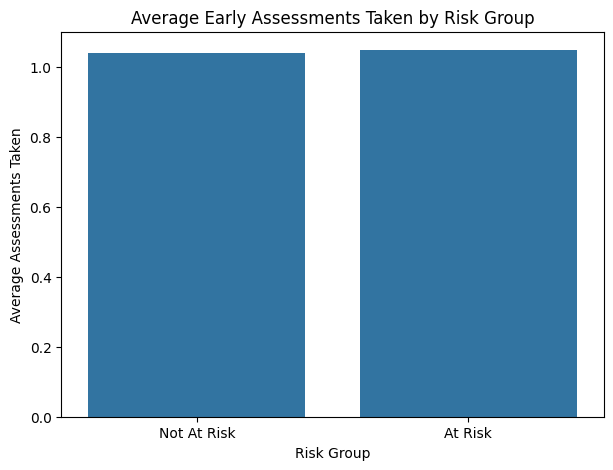

In [20]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=assessment_participation.index,
    y=assessment_participation.values
)

plt.title("Average Early Assessments Taken by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Average Assessments Taken")
plt.show()

## Insight

Early assessment participation does **not** show a meaningful descriptive difference between the two groups.

The average number of early assessments taken is **1.041** for Not At Risk students and **1.048** for At Risk students—a difference of only about **0.007 assessments**.

Therefore, this feature should not be described as a strong standalone risk signal based on this EDA. It may still contribute information in combination with other variables, but the current result suggests that **early assessment score is far more discriminative than assessment count**.


## 4.9 Early VLE Engagement

We compare early online-learning engagement using:
- Total clicks
- Active days
- Active learning sites
- Average clicks per active day

All VLE measures are restricted to the first **28 days**, matching the early-warning feature window.

Because click counts are highly skewed, the total-click distribution is displayed on a logarithmic scale.


In [21]:
engagement_summary = (
    features
    .groupby("is_at_risk")[
        [
            "total_clicks",
            "active_days",
            "active_sites",
            "avg_clicks_per_active_day"
        ]
    ]
    .median()
)

engagement_summary.index = [
    "Not At Risk",
    "At Risk"
]

engagement_summary

,total_clicks,active_days,active_sites,avg_clicks_per_active_day
Not At Risk,292.0,16.0,27.0,19.078462
At Risk,141.0,9.0,19.0,15.307692


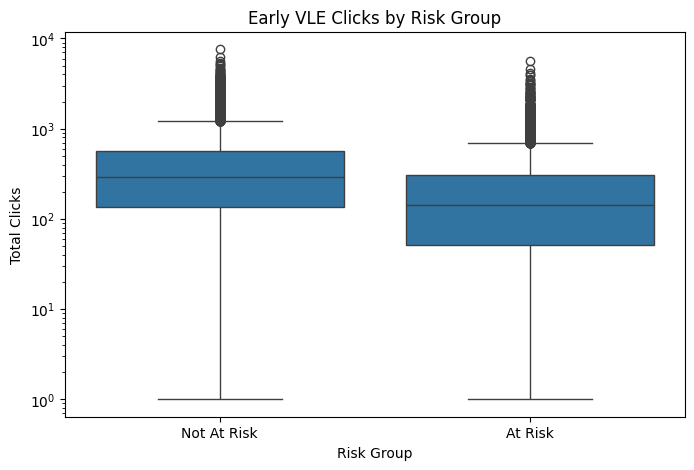

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=features,
    x="is_at_risk",
    y="total_clicks"
)

plt.title("Early VLE Clicks by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Total Clicks")
plt.yscale("log")

plt.xticks(
    [0, 1],
    ["Not At Risk", "At Risk"]
)

plt.show()

## Insight

The engagement summaries show consistently lower early VLE activity among students who were eventually At Risk.

Median values are:

| Feature | Not At Risk | At Risk |
|---|---:|---:|
| Total clicks | 292 | 141 |
| Active days | 16 | 9 |
| Active sites | 27 | 19 |
| Avg. clicks per active day | 19.08 | 15.31 |

The At Risk group therefore has roughly **half the median total clicks** of the Not At Risk group (141 vs 292) and is active on **7 fewer days** during the early window.

The pattern is consistent across all four engagement measures, suggesting that early online participation is a meaningful candidate early-warning signal rather than the difference being driven by one engagement metric alone.


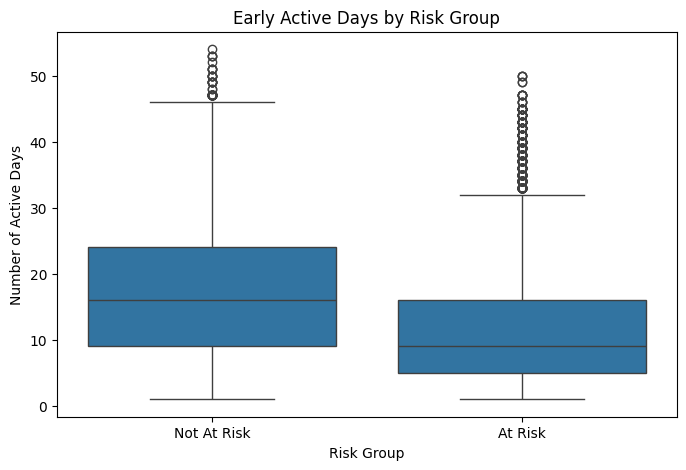

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=features,
    x="is_at_risk",
    y="active_days"
)

plt.title("Early Active Days by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Number of Active Days")

plt.xticks(
    [0, 1],
    ["Not At Risk", "At Risk"]
)

plt.show()

## Insight

`active_days` provides a measure of **consistency of engagement**.

The median is **16 active days** for Not At Risk students compared with **9 days** for At Risk students—a difference of **7 days** within the first 28 days.

This is a substantial descriptive gap: the At Risk group was active on roughly half as many days at the median. Combined with the lower total-click and active-site medians, the result suggests that the difference is not only about the number of clicks, but also about **how consistently students return to the learning platform**.


## 4.10 Students With No Early VLE Activity

We now isolate students with **no recorded VLE activity during the first 28 days**.

This is especially relevant to early intervention because a complete absence of online activity may be easier to identify operationally than a gradual decline in engagement.


In [24]:
no_activity_risk = (
    features
    .groupby("no_early_vle_activity")["is_at_risk"]
    .agg(["mean", "count"])
)

no_activity_risk["risk_percentage"] = (
    no_activity_risk["mean"] * 100
).round(2)

no_activity_risk.index = [
    "Early VLE Activity Present",
    "No Early VLE Activity"
]

no_activity_risk

,mean,count,risk_percentage
Early VLE Activity Present,0.471311,28792,47.13
No Early VLE Activity,0.957117,3801,95.71


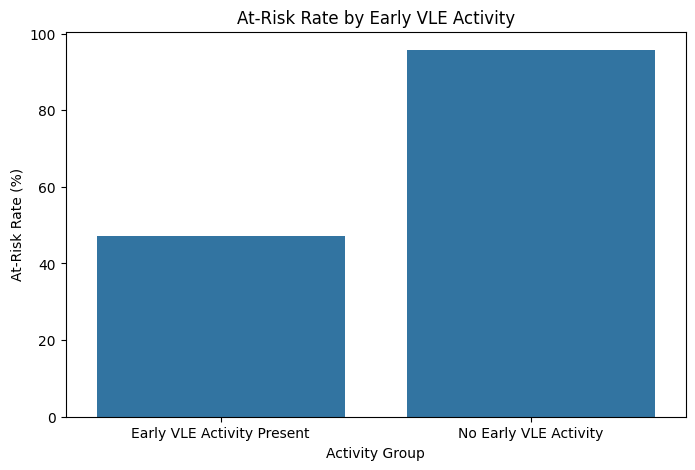

In [25]:
no_activity_risk_reset = no_activity_risk.reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=no_activity_risk_reset,
    x="index",
    y="risk_percentage"
)

plt.title("At-Risk Rate by Early VLE Activity")
plt.xlabel("Activity Group")
plt.ylabel("At-Risk Rate (%)")
plt.show()

## Insight

The no-activity group is the strongest descriptive separation observed in this EDA.

- Students with early VLE activity: **47.13% at risk** (**28,792 records**)
- Students with no early VLE activity: **95.71% at risk** (**3,801 records**)

The difference is about **48.6 percentage points**. In other words, almost **96%** of the records with no recorded VLE activity eventually fall into the Fail/Withdrawn risk group.

This makes `no_early_vle_activity` a particularly important candidate early-warning feature. It should still be validated in the modeling stage, and advisors should distinguish genuine disengagement from cases where platform activity may not have been recorded.


## 4.11 Early Performance vs Engagement

We combine early assessment performance with early VLE engagement to see whether the two dimensions provide overlapping or complementary information.

The x-axis uses a logarithmic scale because total clicks span a very wide range.


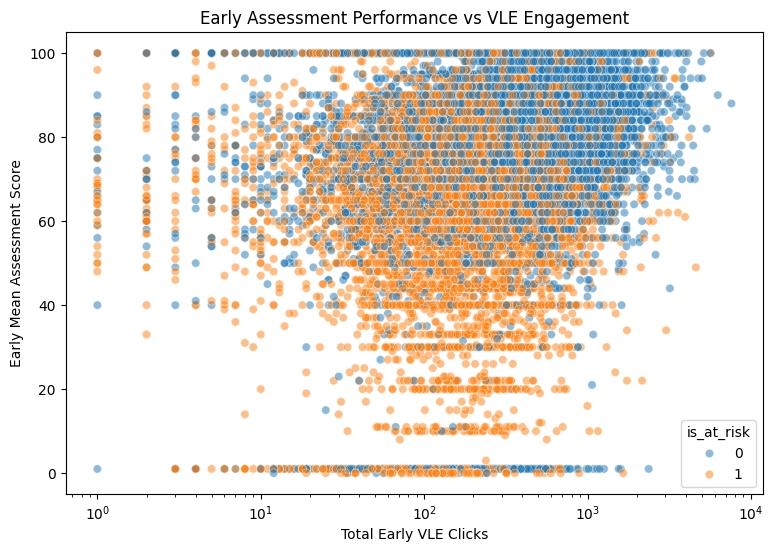

In [26]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=features,
    x="total_clicks",
    y="early_mean_score",
    hue="is_at_risk",
    alpha=0.5
)

plt.xscale("log")

plt.title("Early Assessment Performance vs VLE Engagement")
plt.xlabel("Total Early VLE Clicks")
plt.ylabel("Early Mean Assessment Score")
plt.show()

## Insight

The scatter plot shows substantial overlap between the two outcome groups, so **total clicks alone does not cleanly separate At Risk from Not At Risk students**.

However, the plot also shows a clear concentration of At Risk observations at **lower assessment scores**, particularly across low-to-moderate click levels. Not At Risk observations are more prevalent at higher assessment scores and higher engagement levels.

This supports the idea that academic performance and engagement provide **complementary signals**: a student with both weak early performance and limited VLE activity appears more concerning than a student who is weak on only one dimension.

The plot is descriptive, so the size of the combined predictive contribution will be tested later with validated models rather than inferred from the scatter alone.


## 4.12 Numeric Feature Relationships

We inspect correlations among numeric early-risk features to identify relationships, potential redundancy, and groups of features that measure similar underlying behavior.

Correlation is descriptive and does not establish causation.


In [27]:
numeric_cols = [
    "early_assessments_taken",
    "early_mean_score",
    "early_median_score",
    "early_max_score",
    "early_score_std",
    "early_missing_scores",
    "early_assessment_weight",
    "total_clicks",
    "active_days",
    "active_sites",
    "avg_clicks_per_active_day"
]

corr = features[numeric_cols].corr()

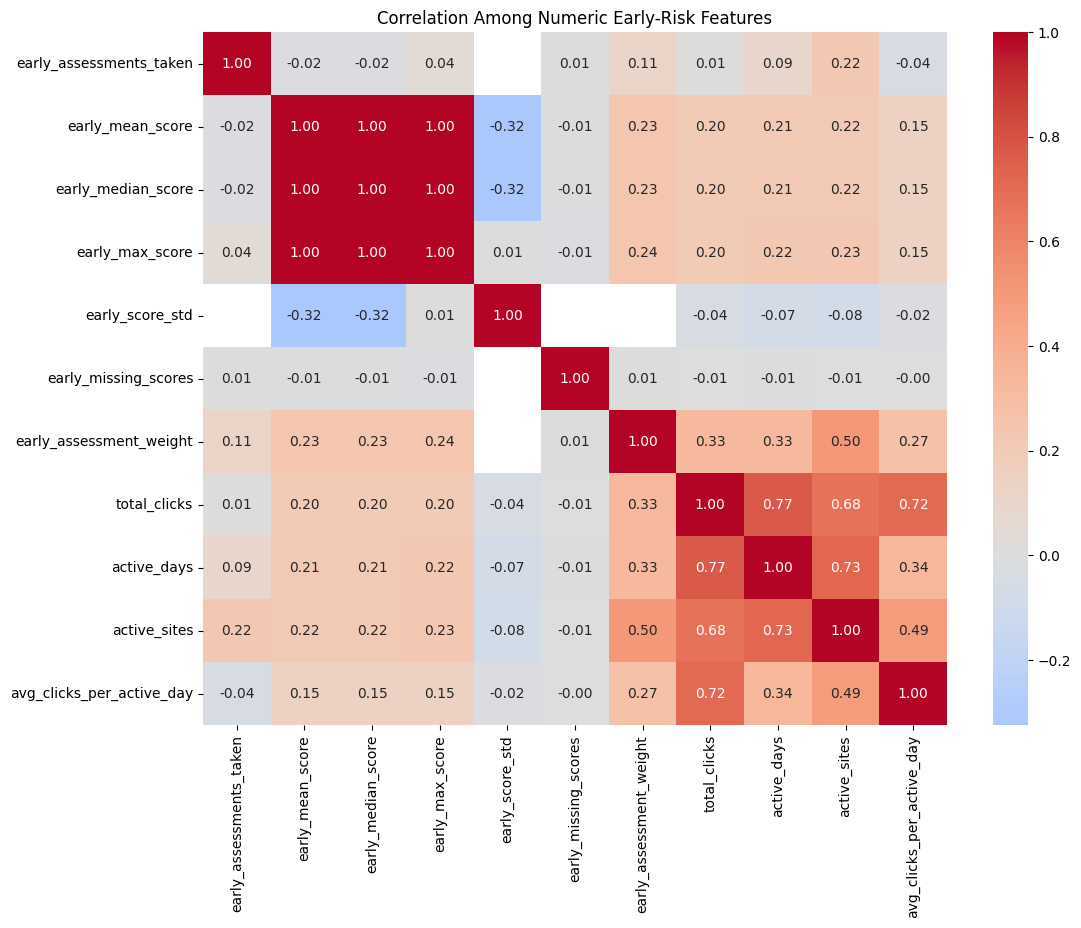

In [28]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Among Numeric Early-Risk Features")
plt.show()

## Insight

The correlation matrix reveals two clear groups of highly related features.

**1. Early score features are almost redundant with one another.**
`early_mean_score`, `early_median_score`, and `early_max_score` have correlations of approximately **1.00** with each other. This is expected because these aggregates are derived from the same small set of early assessment results. `early_score_std` has a moderate negative correlation of about **−0.32** with the score-level aggregates.

**2. VLE engagement measures are strongly related.**
- `total_clicks` vs `active_days`: **0.77**
- `total_clicks` vs `avg_clicks_per_active_day`: **0.72**
- `active_days` vs `active_sites`: **0.73**
- `total_clicks` vs `active_sites`: **0.68**

This indicates that several engagement variables capture overlapping aspects of the same underlying activity. The modeling stage should therefore check whether all of them add useful predictive information rather than assuming every feature contributes independently.

Importantly, high correlation is not by itself a reason to delete a feature; the final decision should depend on model performance, interpretability, and redundancy.


## 4.13 Early Feature Comparison by Risk Group

We summarize the median values of the main early-warning features for the two outcome groups.

Using medians is useful here because engagement variables are highly skewed and can be influenced by extreme values.


In [29]:
feature_comparison = (
    features
    .groupby("is_at_risk")[
        [
            "early_mean_score",
            "early_assessments_taken",
            "total_clicks",
            "active_days",
            "active_sites",
            "avg_clicks_per_active_day"
        ]
    ]
    .median()
    .T
)

feature_comparison.columns = [
    "Not At Risk",
    "At Risk"
]

feature_comparison

,Not At Risk,At Risk
early_mean_score,80.000000,70.000000
early_assessments_taken,1.000000,1.000000
total_clicks,292.000000,141.000000
active_days,16.000000,9.000000
active_sites,27.000000,19.000000
avg_clicks_per_active_day,19.078462,15.307692


## Insight

The median comparison reinforces the main EDA pattern:

| Feature | Not At Risk | At Risk |
|---|---:|---:|
| Early mean score | 80.0 | 70.0 |
| Early assessments taken | 1.0 | 1.0 |
| Total clicks | 292.0 | 141.0 |
| Active days | 16.0 | 9.0 |
| Active sites | 27.0 | 19.0 |
| Avg. clicks per active day | 19.08 | 15.31 |

Three points stand out:

1. **Early performance:** the median score is 10 points lower in the At Risk group.
2. **Engagement:** the At Risk group has substantially lower median clicks, active days, and active sites.
3. **Assessment participation:** both groups have the same median of 1 assessment, confirming that assessment count alone does not separate the groups well.

These descriptive differences provide a focused set of candidate predictors for the modeling stage, while validated model performance will determine which features are actually useful for prediction.


# 4.14 EDA Findings

The exploratory analysis provides evidence relevant to the Student Success Office's six case-study questions.

The findings below are based on the **observed outputs in this notebook** and should be treated as descriptive associations until validated through modeling.


### Question 1 - Which factors are associated with risk?

The clearest observed differences are in **early assessment performance and VLE engagement**.

At Risk students have a mean early assessment score of **65.95**, compared with **76.96** for Not At Risk students. Engagement is also consistently lower: median total clicks are **141 vs 292**, active days **9 vs 16**, and active sites **19 vs 27**.

Course module, age, education, and IMD band also show different observed risk rates, so they provide useful contextual information to test alongside behavioral features.

### Question 2 - How early can risk be detected?

This notebook deliberately uses information available within the **first 28 days**. The EDA therefore shows that useful differences are already visible by that point, especially in early scores and online engagement.

However, this notebook does **not** prove that 28 days is the earliest possible detection point. Testing earlier cutoffs such as 7, 14, or 21 days would be needed to answer that question directly.

### Question 3 - Do demographic groups differ in risk?

Yes, the observed rates differ across all three examined contextual dimensions:

- Age: **54.97%** for 0–35 vs **47.84%** for 35–55 vs **38.43%** for 55≤.
- Education: **70.32%** for No Formal quals vs **34.50%** for Post Graduate Qualification, with small sample sizes at both extremes.
- IMD: **64.84%** for 0–10% vs **42.47%** for 90–100%.

These are associations and should not be interpreted as demographic causes of poor outcomes.

### Question 4 - How does online activity relate to outcomes?

The relationship is strong descriptively. Students with no recorded early VLE activity have a **95.71%** at-risk rate, compared with **47.13%** among students with activity.

Among students with activity, the At Risk group also has lower median total clicks, active days, active sites, and clicks per active day.

### Question 5 - Which assessments provide the strongest early signal?

The current EDA demonstrates that **aggregated early assessment performance** is strongly associated with the final risk group, with an approximately **11-point difference in mean score**.

However, this notebook does **not** compare individual assessment IDs or checkpoints. Therefore, it cannot yet identify which specific assessment is the strongest signal. That requires a separate assessment-level analysis.

### Question 6 - Why is a student flagged?

EDA identifies candidate signals but does not explain an individual model prediction. Individual explanations will be addressed later using model interpretability methods, where we can show which features pushed a specific student's predicted risk higher or lower.


# 4.15 EDA Summary

### Key Findings

- The target is relatively balanced: **52.8% At Risk vs 47.2% Not At Risk**.
- Risk varies substantially by course module, with observed rates ranging from **29.01% in AAA to 62.16% in CCC**.
- Age, prior education, and IMD band show meaningful descriptive differences in risk, although small groups require cautious interpretation.
- Early assessment **performance** is a strong descriptive signal: mean early score is **65.95 for At Risk vs 76.96 for Not At Risk**.
- Early assessment **participation count is not strongly different** between the groups, so it should not be treated as a major standalone signal based on this EDA.
- Early VLE engagement is consistently lower among At Risk students: median clicks **141 vs 292**, active days **9 vs 16**, and active sites **19 vs 27**.
- The clearest single descriptive separation is the absence of early VLE activity: **95.71%** of students with no early activity are At Risk.
- Several VLE features are strongly correlated with each other, while the three main early score aggregates are almost perfectly correlated. This indicates potential redundancy that should be considered during modeling.
- The combination of academic performance and engagement appears more informative descriptively than either dimension alone, but predictive value must be confirmed through validation.

### Next Step

The next notebook will move from descriptive EDA to **predictive modeling**. Candidate models will be evaluated using validation data and risk-focused metrics to determine whether these observed patterns translate into reliable early-risk predictions.
